# Исследование данных федерального медицинского центра ФГБОУ ВО СПбГПМУ.

## Цели и задачи проекта

В этом проекте нам предстоит проанализировать данные федерального медицинского центра ФГБОУ ВО СПбГПМУ.

Наша цель – узнать, какие факторы влияют на время, которое занимает процесс от выдачи направления до поступления в медицинский центр.

## Описание данных

Мы будем работать с таблицей `hospital.csv` — в ней данные федерального медицинского центра ФГБОУ ВО СПбГПМУ.

Поля таблицы `hospital.csv` :
- `ДАТА_ПОСТУПЛЕНИЯ` — дата поступления пациента в отделение;
- `ДАТА_ВЫПИСКИ` — дата выписки пациента из отделения;
- `УНИКАЛЬНЫЙ_ID` — идентификатор пациента;
- `НОМЕР_ИБ` — системное поле (номер информационной безопасности);
- `ШИФР` — системное поле;
- `РЕГИОН` — регион проживания пациента;
- `ПЛАТЕЛЬЩИК` — наименование плательщика;
- `ИСТОЧНИК_ФИНАНСИРОВАНИЯ` — ОМС или другой вариант;
- `ОТДЕЛЕНИЕ`— название отделения;
- `ПРОФИЛЬ` — профиль отделения (например, терапия, хирургия);
- `КОЙКО_ДНИ` — количество дней лечения в стационаре;
- `ПЛАНОВО_ЭКСТРЕННО`— поступил планово или экстренно;
- `КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ` — код диагноза при поступлении;
- `КОД_МКБ_ПРИ_ВЫПИСКЕ`— код диагноза при выписке.

## Загрузка и знакомство с данными

In [1]:
# Импортируем библиотеку pandas
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные из датасета hospital.csv
hospital = pd.read_csv("hospital.csv")

In [3]:
# Выводим информацию о датафрейме hospital
hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125261 entries, 0 to 125260
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   ДАТА_ПОСТУПЛЕНИЯ         125261 non-null  object 
 1   ДАТА_ВЫПИСКИ             125261 non-null  object 
 2   УНИКАЛЬНЫЙ_ID            125261 non-null  int64  
 3   НОМЕР_ИБ                 125261 non-null  int64  
 4   ШИФР                     125261 non-null  object 
 5   РЕГИОН                   56391 non-null   object 
 6   ПЛАТЕЛЬЩИК               125261 non-null  object 
 7   ИСТОЧНИК_ФИНАНСИРОВАНИЯ  125261 non-null  object 
 8   ОТДЕЛЕНИЕ                125261 non-null  object 
 9   ПРОФИЛЬ                  125261 non-null  object 
 10  КОЙКО_ДНИ                125261 non-null  float64
 11  ПЛАНОВО_ЭКСТРЕННО        125261 non-null  object 
 12  КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ  125253 non-null  object 
 13  КОД_МКБ_ПРИ_ВЫПИСКЕ      125257 non-null  object 
dtypes: f

In [4]:
# Выводим первые строки датафрейма на экран
hospital.head()

,ДАТА_ПОСТУПЛЕНИЯ,ДАТА_ВЫПИСКИ,УНИКАЛЬНЫЙ_ID,НОМЕР_ИБ,ШИФР,РЕГИОН,ПЛАТЕЛЬЩИК,ИСТОЧНИК_ФИНАНСИРОВАНИЯ,ОТДЕЛЕНИЕ,ПРОФИЛЬ,КОЙКО_ДНИ,ПЛАНОВО_ЭКСТРЕННО,КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ,КОД_МКБ_ПРИ_ВЫПИСКЕ
0,01.01.2019,10.01.2019,858042000,1,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Микрохирургическое отделение,Сосудистой хирургии,10.0,Экстренная,S61.7,S66.4
1,01.01.2019,01.01.2019,993109000,3,5.13.1,NaN,"СПб филиал ООО ""СМК РЕСО - Мед""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
2,01.01.2019,01.01.2019,993111000,4,5.12.1,NaN,"ООО ""Капитал Медицинское Страхование""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
3,01.01.2019,07.01.2019,993110000,2,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Инфекционное отделение №1,Инфекционные,7.0,Экстренная,B27.9,J03.9
4,01.01.2019,05.01.2019,987185000,5,1.1.1,NaN,Коммерческие,Наличный расчет,ПЦ Акушерское физиологическое отделение,Для беременных и рожениц,5.0,Плановая,O42.9,O82.1


In [5]:
# Проверим пропуски
missing_values = hospital.isna().sum().sort_values(ascending=False)
missing_values

РЕГИОН                     68870
КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ        8
КОД_МКБ_ПРИ_ВЫПИСКЕ            4
ДАТА_ПОСТУПЛЕНИЯ               0
ДАТА_ВЫПИСКИ                   0
УНИКАЛЬНЫЙ_ID                  0
НОМЕР_ИБ                       0
ШИФР                           0
ПЛАТЕЛЬЩИК                     0
ИСТОЧНИК_ФИНАНСИРОВАНИЯ        0
ОТДЕЛЕНИЕ                      0
ПРОФИЛЬ                        0
КОЙКО_ДНИ                      0
ПЛАНОВО_ЭКСТРЕННО              0
dtype: int64

In [6]:
# Проверим процент пропусков
missing_percent = (hospital.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percent': missing_percent
}).sort_values(by='missing_count', ascending=False)

missing_table

,missing_count,missing_percent
РЕГИОН,68870,54.98
КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ,8,0.01
КОД_МКБ_ПРИ_ВЫПИСКЕ,4,0.00
ДАТА_ВЫПИСКИ,0,0.00
ДАТА_ПОСТУПЛЕНИЯ,0,0.00
ИСТОЧНИК_ФИНАНСИРОВАНИЯ,0,0.00
КОЙКО_ДНИ,0,0.00
НОМЕР_ИБ,0,0.00
ОТДЕЛЕНИЕ,0,0.00
ПЛАНОВО_ЭКСТРЕННО,0,0.00


В этом файле есть пропуски в таких столбцах:
    
- `region` — 68 870 пропусков, примерно 54.98%
- `icd_code_admission` — 8 пропусков
- `icd_code_discharge` — 4 пропуска

In [7]:
# Проверяем дубликаты
hospital.duplicated().sum()

4415

### Промежуточный вывод по этапу подготовки данных
До обработки датасет содержит 125 261 строку и 14 столбцов. В таблице представлены данные о госпитализациях пациентов: даты поступления и выписки, регион проживания, плательщик, источник финансирования, отделение, профиль, количество койко-дней, тип поступления и коды диагнозов по МКБ.

На первый взгляд структура данных подходит для дальнейшего анализа, однако перед исследованием требуется предобработка.

Названия столбцов представлены на русском языке, в верхнем регистре и с использованием подчёркиваний. Для дальнейшей работы с данными их лучше привести к более удобному и единообразному формату — например, к коротким названиям в стиле `snake_case` на английском языке. Это упростит написание кода, обращение к столбцам и дальнейший анализ.

В данных обнаружены пропуски. Наиболее проблемный столбец — `РЕГИОН`: в нём отсутствует 68 870 значений, что составляет примерно 55% от всех записей. Это важный фактор, так как регион проживания может влиять на процесс поступления пациента в медицинский центр. Удалять такие строки нельзя, потому что будет потеряна значительная часть данных.

Также есть небольшое количество пропусков в столбцах с кодами МКБ: 8 пропусков в `КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ` и 4 пропуска в `КОД_МКБ_ПРИ_ВЫПИСКЕ`. Их доля очень мала, поэтому они не окажут существенного влияния на общий анализ.

Типы данных требуют корректировки. Столбцы с датами поступления и выписки имеют тип `object`, то есть хранятся как текст. Для дальнейшего анализа их необходимо преобразовать в формат даты `datetime`. Столбец `КОЙКО_ДНИ` имеет тип `float64`, хотя количество дней лечения является целым числом, поэтому его можно преобразовать в `int`.

В датасете также обнаружены полные дубликаты строк — 4 415 записей. Перед анализом их необходимо изучить и, при подтверждении полного совпадения, удалить, чтобы они не искажали результаты.

Таким образом, до обработки данные нельзя считать полностью готовыми к анализу. Основные проблемы датасета: большое количество пропусков в регионе, некорректные типы данных для дат и койко-дней, а также наличие полных дубликатов.

## Предобработка данных

In [8]:
# Переименуем столбцы
hospital = hospital.rename(columns={
    'ДАТА_ПОСТУПЛЕНИЯ': 'admission_date',
    'ДАТА_ВЫПИСКИ': 'discharge_date',
    'УНИКАЛЬНЫЙ_ID': 'patient_id',
    'НОМЕР_ИБ': 'medical_record_number',
    'ШИФР': 'department_code',
    'РЕГИОН': 'region',
    'ПЛАТЕЛЬЩИК': 'payer',
    'ИСТОЧНИК_ФИНАНСИРОВАНИЯ': 'funding_source',
    'ОТДЕЛЕНИЕ': 'department',
    'ПРОФИЛЬ': 'department_profile',
    'КОЙКО_ДНИ': 'bed_days',
    'ПЛАНОВО_ЭКСТРЕННО': 'admission_type',
    'КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ': 'icd_code_admission',
    'КОД_МКБ_ПРИ_ВЫПИСКЕ': 'icd_code_discharge'
})

In [9]:
# Проверим результат
hospital.columns.tolist()

['admission_date',
 'discharge_date',
 'patient_id',
 'medical_record_number',
 'department_code',
 'region',
 'payer',
 'funding_source',
 'department',
 'department_profile',
 'bed_days',
 'admission_type',
 'icd_code_admission',
 'icd_code_discharge']

В регионе очень много пропусков — почти 55%. Удалять такие строки нельзя, потому что мы потеряем половину данных.
Лучше заменить пропуски на значение "Не указан".

In [10]:
# Обрабатываем пропуски 
hospital['region'] = hospital['region'].fillna('Не указан')

В столбцах с диагнозами пропусков очень мало. Их тоже можно заменить на "Не указан".

In [11]:
hospital['icd_code_admission'] = hospital['icd_code_admission'].fillna('Не указан')
hospital['icd_code_discharge'] = hospital['icd_code_discharge'].fillna('Не указан')

In [12]:
# Проверим остались ли пропуски
hospital.isna().sum()

admission_date           0
discharge_date           0
patient_id               0
medical_record_number    0
department_code          0
region                   0
payer                    0
funding_source           0
department               0
department_profile       0
bed_days                 0
admission_type           0
icd_code_admission       0
icd_code_discharge       0
dtype: int64

In [13]:
# Меняем типы данных
hospital['admission_date'] = pd.to_datetime(
    hospital['admission_date'], 
    format='%d.%m.%Y',
    errors='coerce'
)

hospital['discharge_date'] = pd.to_datetime(
    hospital['discharge_date'], 
    format='%d.%m.%Y',
    errors='coerce'
)

In [14]:
hospital['bed_days'] = hospital['bed_days'].astype(int)

In [15]:
# Проверим типы данных
hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125261 entries, 0 to 125260
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   admission_date         125261 non-null  datetime64[ns]
 1   discharge_date         125261 non-null  datetime64[ns]
 2   patient_id             125261 non-null  int64         
 3   medical_record_number  125261 non-null  int64         
 4   department_code        125261 non-null  object        
 5   region                 125261 non-null  object        
 6   payer                  125261 non-null  object        
 7   funding_source         125261 non-null  object        
 8   department             125261 non-null  object        
 9   department_profile     125261 non-null  object        
 10  bed_days               125261 non-null  int64         
 11  admission_type         125261 non-null  object        
 12  icd_code_admission     125261 non-null  obje

In [16]:
# Удалим дубликаты
hospital = hospital.drop_duplicates()

In [17]:
hospital.duplicated().sum()

0

**Итоговая проверка датафрейма**

In [18]:
hospital.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 120846 entries, 0 to 125260
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   admission_date         120846 non-null  datetime64[ns]
 1   discharge_date         120846 non-null  datetime64[ns]
 2   patient_id             120846 non-null  int64         
 3   medical_record_number  120846 non-null  int64         
 4   department_code        120846 non-null  object        
 5   region                 120846 non-null  object        
 6   payer                  120846 non-null  object        
 7   funding_source         120846 non-null  object        
 8   department             120846 non-null  object        
 9   department_profile     120846 non-null  object        
 10  bed_days               120846 non-null  int64         
 11  admission_type         120846 non-null  object        
 12  icd_code_admission     120846 non-null  obje

### Промежуточный вывод по этапу предобработки данных

На этапе предобработки данных были выполнены основные шаги подготовки данных к дальнейшему анализу.

Сначала названия столбцов были приведены к более удобному формату `snake_case` на английском языке. Это упростит дальнейшее обращение к признакам и написание кода.

Затем были обработаны пропущенные значения. Пропуски в столбце `region`, где отсутствовала значительная часть данных, были заменены на значение `"Не указан"`, так как удаление таких строк привело бы к потере большого объёма информации. Также были заполнены пропуски в столбцах `icd_code_admission` и `icd_code_discharge`, где отсутствующие значения также заменены на `"Не указан"`. После обработки пропусков в датасете не осталось.

Далее были скорректированы типы данных. Столбцы `admission_date` и `discharge_date` были преобразованы в формат `datetime`, так как они содержат даты поступления и выписки пациентов. Столбец `bed_days` был преобразован в целочисленный тип `int64`, поскольку количество койко-дней является целым числом.

Также были проверены и удалены полные дубликаты строк. После удаления дубликатов в датасете осталось 120 846 записей и 14 столбцов. Повторяющихся строк больше не обнаружено.

Таким образом, после предобработки данные стали пригодны для дальнейшего исследовательского анализа: названия столбцов приведены к удобному формату, пропуски обработаны, типы данных исправлены, а дубликаты удалены.


## Исследовательский анализ данных

**1. Распределение длительности госпитализации**

In [19]:
# Посмотрим основные статистики по длительности госпитализации
hospital['bed_days'].describe()

count    120846.000000
mean          8.730988
std           8.776465
min           1.000000
25%           3.000000
50%           7.000000
75%          12.000000
max         266.000000
Name: bed_days, dtype: float64

In [20]:
# Посмотрим процентили
hospital['bed_days'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25     3.0
0.50     7.0
0.75    12.0
0.90    17.0
0.95    22.0
0.99    37.0
Name: bed_days, dtype: float64

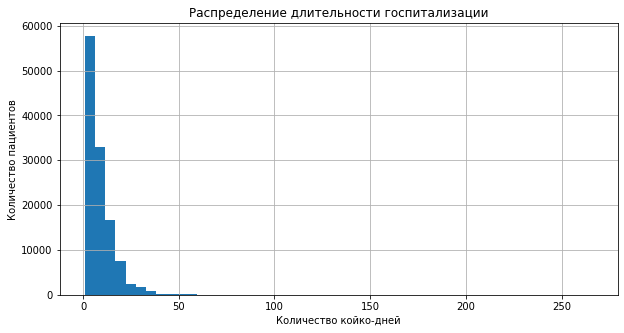

In [21]:
# Строим гистограмму
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
hospital['bed_days'].hist(bins=50)

plt.title('Распределение длительности госпитализации')
plt.xlabel('Количество койко-дней')
plt.ylabel('Количество пациентов')
plt.show()

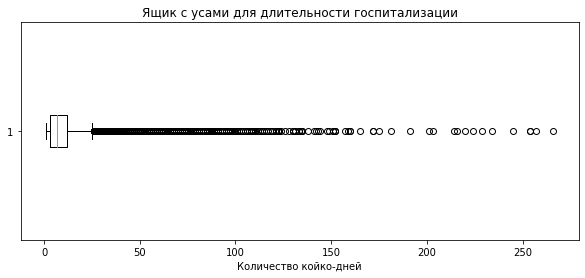

In [22]:
# Построим ящик с усами
plt.figure(figsize=(10, 4))
plt.boxplot(hospital['bed_days'], vert=False)

plt.title('Ящик с усами для длительности госпитализации')
plt.xlabel('Количество койко-дней')
plt.show()

**Вывод**

Распределение длительности госпитализации имеет выраженную правостороннюю асимметрию: большинство пациентов находились в стационаре относительно недолго, но в данных есть отдельные случаи очень длительной госпитализации.

Всего в анализе учитывается 120 846 записей. Средняя длительность госпитализации составляет около 8,7 койко-дня, а медианная — 7 дней. Так как среднее значение выше медианы, можно сделать вывод, что на него влияют редкие длительные госпитализации.

Основная часть пациентов находилась в стационаре от 3 до 12 дней: первый квартиль равен 3 дням, третий квартиль — 12 дням. При этом 90% госпитализаций длились не более 17 дней, 95% — не более 22 дней, а 99% — не более 37 дней.

Максимальное значение составляет 266 койко-дней. На boxplot видно большое количество значений за пределами «усов», то есть потенциальных выбросов. Однако в медицинских данных такие значения не обязательно являются ошибками: они могут отражать сложные клинические случаи, длительное лечение или особенности отдельных отделений.

Таким образом, типичная длительность госпитализации составляет около одной недели, но в датасете присутствуют редкие случаи значительно более длительного пребывания пациентов в стационаре. Для дальнейшего анализа важно учитывать, что среднее значение может искажаться выбросами, поэтому медиана лучше описывает типичную длительность госпитализации.


**2. Средняя длительность госпитализации по отделениям**

Топ-10 отделений с наибольшей средней длительностью госпитализации

In [23]:
# Посчитаем среднюю длительность госпитализации по отделениям
department_bed_days = (
    hospital
    .groupby('department', as_index=False)
    .agg(
        avg_bed_days=('bed_days', 'mean'),
        median_bed_days=('bed_days', 'median'),
        patients_count=('patient_id', 'count')
    )
    .sort_values(by='avg_bed_days', ascending=False)
)

department_bed_days.head(10)

,department,avg_bed_days,median_bed_days,patients_count
14,Отделение анестезиологии-реанимации,45.179487,8.0,78
20,ПЦ ОАРИТН №1 (новорожденных),28.723214,11.0,112
21,ПЦ Отделение Анестезиологии-реанимации для дет...,26.438095,18.0,105
24,ПЦ Отделение патологии новорожденных и детей г...,22.200586,14.0,2388
22,ПЦ Отделение вспомогательных репродуктивных те...,21.297802,20.0,910
3,Дневной стационар Кожно-венерологического отде...,14.027322,15.0,183
2,Дневной стационар Гастроэнтерологического отде...,13.339286,13.0,280
12,Микрохирургическое отделение,13.293007,10.0,4662
27,Педиатрическое отделение №1,12.824642,12.0,3490
8,Дневной стационар эндокринологического отд.,12.766667,13.0,60


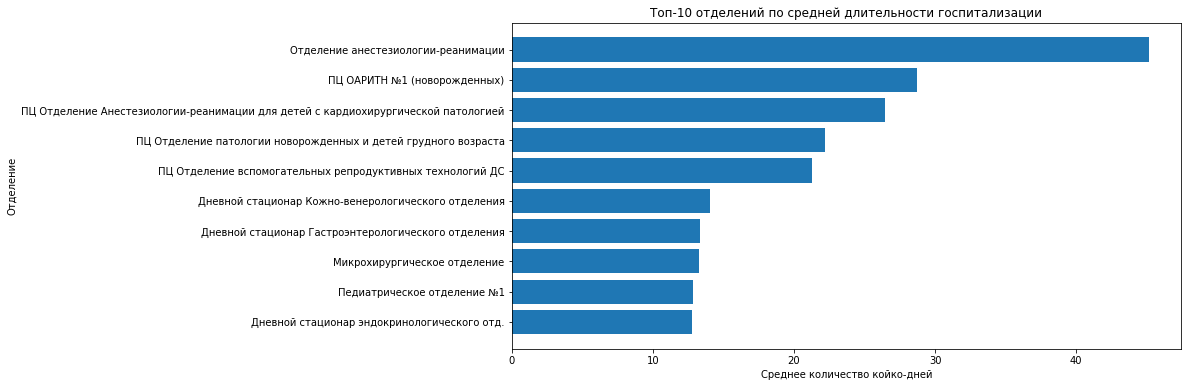

In [24]:
# Построим график
plt.figure(figsize=(12, 6))

plt.barh(
    department_bed_days.head(10)['department'],
    department_bed_days.head(10)['avg_bed_days']
)

plt.title('Топ-10 отделений по средней длительности госпитализации')
plt.xlabel('Среднее количество койко-дней')
plt.ylabel('Отделение')

plt.gca().invert_yaxis()
plt.show()

**Вывод**

Анализ средней длительности госпитализации по отделениям показал, что самые высокие значения наблюдаются в отделениях, связанных с реанимацией, интенсивной терапией, патологией новорождённых и сложными клиническими случаями.

Наибольшая средняя длительность госпитализации отмечается в отделении анестезиологии-реанимации — около 45 дней. Также высокие значения наблюдаются в отделениях реанимации новорождённых, патологии новорождённых и детей грудного возраста, а также во вспомогательных репродуктивных технологиях.

Однако при интерпретации результатов важно учитывать количество пациентов в каждом отделении. В некоторых отделениях число наблюдений небольшое, поэтому среднее значение может быть чувствительно к отдельным длительным госпитализациям. Поэтому вместе со средним значением была рассчитана медиана и количество пациентов.

В целом можно сделать вывод, что длительность госпитализации заметно различается между отделениями. Это может быть связано со спецификой заболеваний, тяжестью состояния пациентов, профилем отделения и особенностями лечения.

**3. Исследуем динамику количества поступивших пациентов в разные месяцы (учитывая различия в годах)**

In [25]:
# Создадим отдельный столбец, где будет храниться
hospital['admission_month'] = hospital['admission_date'].dt.to_period('M').dt.to_timestamp()

In [26]:
# Посчитаем количество поступивших пациентов по каждому месяцу:
monthly_admissions = (
    hospital
    .groupby('admission_month', as_index=False)
    .agg(patients_count=('patient_id', 'count'))
)

monthly_admissions.head()

,admission_month,patients_count
0,2019-01-01,1775
1,2019-02-01,1927
2,2019-03-01,2080
3,2019-04-01,2205
4,2019-05-01,2020


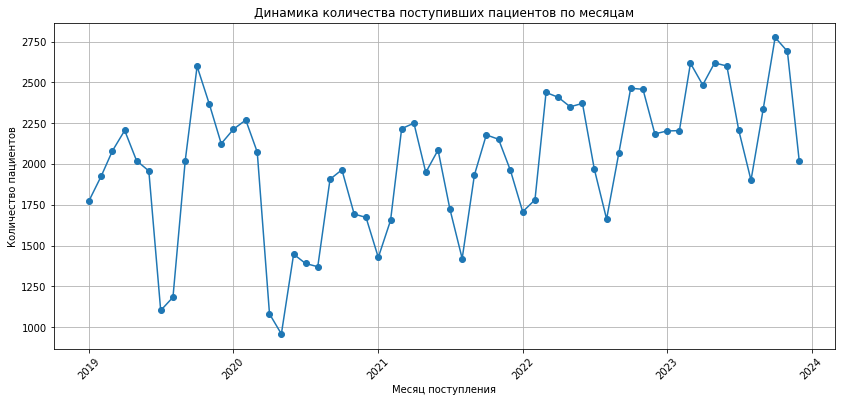

In [27]:
# График динамики поступлений
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_admissions['admission_month'],
    monthly_admissions['patients_count'],
    marker='o'
)

plt.title('Динамика количества поступивших пациентов по месяцам')
plt.xlabel('Месяц поступления')
plt.ylabel('Количество пациентов')

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Вывод**

Для анализа динамики поступлений был создан отдельный признак `admission_month`, который отражает месяц и год поступления пациента. Это позволило корректно сгруппировать данные по времени и не смешивать одинаковые месяцы разных лет.

График показывает, что количество поступивших пациентов менялось неравномерно. В период с 2019 по 2023 год заметны как месяцы с ростом числа госпитализаций, так и периоды снижения.

В 2019 году количество поступлений в большинстве месяцев находилось примерно на уровне 1800–2600 пациентов. В 2020 году наблюдается резкое снижение числа поступивших пациентов: в отдельные месяцы показатель опускался примерно до 1000 пациентов. Вероятно, это может быть связано с внешними ограничениями и изменениями в работе медицинских учреждений в период пандемии COVID-19.

Начиная с 2021 года количество поступлений постепенно восстанавливается. В 2022–2023 годах поток пациентов становится выше и стабильнее: во многих месяцах количество поступивших превышает 2200–2500 человек. К концу рассматриваемого периода видны одни из самых высоких значений — около 2700–2800 пациентов в месяц.

Также на графике заметны сезонные колебания: в течение каждого года есть месяцы с локальными подъёмами и снижениями. Это может быть связано с особенностями плановой госпитализации, праздничными периодами, каникулами, сезонностью заболеваний или организационными факторами внутри медицинского центра.

Таким образом, динамика поступлений показывает общий рост количества пациентов после снижения в 2020 году. Для дальнейшего анализа можно отдельно сравнить динамику по отделениям, типу поступления — плановому или экстренному, а также по источникам финансирования.


## Проверка гипотез

**Задача 1**

Руководство хочет проверить, отличается ли средняя длительность госпитализации пациентов от стандартного семидневного срока. Проверим эту гипотезу.

**1. Форулируем гипотезы**

H₀: средняя длительность госпитализации пациентов равна 7 дням.

H₁: средняя длительность госпитализации пациентов отличается от 7 дней.

**2. Проведём статистический тест**

In [28]:
# Средняя длительность госпитализации
hospital['bed_days'].mean()

8.73098819985767

In [29]:
from scipy import stats

# стандартный срок госпитализации
standard_days = 7

# уровень значимости
alpha = 0.05

# одновыборочный t-тест
t_stat, p_value = stats.ttest_1samp(
    hospital['bed_days'],
    popmean=standard_days
)

print('t-статистика:', t_stat)
print('p-value:', p_value)

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

t-статистика: 68.5631282640259
p-value: 0.0
Отвергаем нулевую гипотезу


### Вывод по проверке гипотезы

Для проверки гипотезы о том, отличается ли средняя длительность госпитализации пациентов от стандартного семидневного срока, был применён одновыборочный t-тест.

В качестве нулевой гипотезы было принято предположение, что средняя длительность госпитализации равна 7 дням. Альтернативная гипотеза состояла в том, что средняя длительность госпитализации отличается от 7 дней.

Уровень значимости был выбран равным 0.05. По результатам теста значение p-value оказалось меньше уровня значимости, поэтому нулевая гипотеза была отвергнута.

Средняя длительность госпитализации в датасете составляет примерно 8,7 койко-дня, что выше стандартного значения в 7 дней. Следовательно, можно сделать вывод, что средняя длительность госпитализации пациентов статистически значимо отличается от стандартного семидневного срока.

При этом важно учитывать, что в данных присутствуют редкие случаи очень длительной госпитализации, которые могут увеличивать среднее значение. Поэтому для дополнительной интерпретации стоит учитывать не только среднее, но и медиану, которая составляет 7 дней.


**Задача 2**

Медицинский отдел хочет проверить, превышает ли средняя длительность госпитализации пациентов 10 дней.

**1. Форулируем гипотезы**

H₀: средняя длительность госпитализации пациентов не превышает 10 дней.

H₁: средняя длительность госпитализации пациентов превышает 10 дней.

то есть:
    
H₀: μ ≤ 10

H₁: μ > 10

**2. Проводим статистический тест**

In [30]:
# стандартное значение для проверки
standard_days = 10

# уровень значимости
alpha = 0.05

# одновыборочный t-тест, односторонняя проверка
t_stat, p_value = stats.ttest_1samp(
    hospital['bed_days'],
    popmean=standard_days,
    alternative='greater'
)

print('t-статистика:', t_stat)
print('p-value:', p_value)

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

t-статистика: -50.26459384811239
p-value: 1.0
Не получилось отвергнуть нулевую гипотезу


### Вывод по проверке гипотезы

Для проверки гипотезы о том, превышает ли средняя длительность госпитализации пациентов 10 дней, был применён одновыборочный t-тест с односторонней альтернативной гипотезой.

Нулевая гипотеза: средняя длительность госпитализации пациентов не превышает 10 дней.

Альтернативная гипотеза: средняя длительность госпитализации пациентов превышает 10 дней.

Уровень значимости был выбран равным 0.05. По результатам теста значение p-value составило 1.0, что значительно больше уровня значимости. Поэтому нет оснований отвергнуть нулевую гипотезу.

Также t-статистика получилась отрицательной, что говорит о том, что средняя длительность госпитализации в выборке ниже 10 дней, а не выше.

Таким образом, на основе имеющихся данных нельзя утверждать, что средняя длительность госпитализации пациентов превышает 10 дней. Средняя длительность госпитализации, наоборот, находится ниже проверяемого значения.



**Задача 3**

Необходимо проверить, отличается ли средняя длительность лечения в стационаре между плановыми и экстренными пациентами.

Для этой задачи нужно сравнить две независимые группы:

- плановые пациенты;
- экстренные пациенты.

Подойдёт двухвыборочный t-тест для независимых выборок.

**1. Форулируем гипотезы**

H₀: средняя длительность лечения в стационаре у плановых и экстренных пациентов не отличается.

H₁: средняя длительность лечения в стационаре у плановых и экстренных пациентов отличается.

то есть:
    
H₀: μ₁ = μ₂

H₁: μ₁ ≠ μ₂

**2. Проводим статистический тест**

In [31]:
# уровень значимости
alpha = 0.05

# выделяем две группы
planned = hospital[hospital['admission_type'] == 'Плановая']['bed_days']
emergency = hospital[hospital['admission_type'] == 'Экстренная']['bed_days']

# двухвыборочный t-тест для независимых выборок
t_stat, p_value = stats.ttest_ind(
    planned,
    emergency,
    equal_var=False
)

print('Средняя длительность лечения плановых пациентов:', planned.mean())
print('Средняя длительность лечения экстренных пациентов:', emergency.mean())
print('t-статистика:', t_stat)
print('p-value:', p_value)

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Средняя длительность лечения плановых пациентов: 9.719045084243659
Средняя длительность лечения экстренных пациентов: 6.251060121986639
t-статистика: 60.11252217601822
p-value: 0.0
Отвергаем нулевую гипотезу


### Вывод по проверке гипотезы

Для проверки гипотезы о том, отличается ли средняя длительность лечения в стационаре между плановыми и экстренными пациентами, был применён двухвыборочный t-тест для независимых выборок.

Нулевая гипотеза: средняя длительность лечения у плановых и экстренных пациентов не отличается.

Альтернативная гипотеза: средняя длительность лечения у плановых и экстренных пациентов отличается.

Уровень значимости был выбран равным 0.05. По результатам теста p-value оказалось меньше уровня значимости, поэтому нулевая гипотеза была отвергнута. Это означает, что различие в средней длительности лечения между плановыми и экстренными пациентами является статистически значимым.

Средняя длительность лечения плановых пациентов составляет около 9,7 койко-дня, а экстренных пациентов — около 6,3 койко-дня. Таким образом, плановые пациенты в среднем находятся в стационаре дольше, чем экстренные.

Можно предположить, что это связано со спецификой плановой госпитализации: такие пациенты могут проходить более длительное обследование, подготовку к процедурам, операции или восстановление после лечения. Экстренные пациенты, наоборот, могут поступать для более краткосрочной неотложной помощи.


## Общий вывод

В ходе исследования были проанализированы данные о госпитализациях пациентов медицинского центра. Датасет содержал информацию о датах поступления и выписки, регионе, плательщике, источнике финансирования, отделении, профиле, количестве койко-дней, типе поступления и кодах диагнозов по МКБ.

На этапе предобработки данные были подготовлены к анализу: названия столбцов приведены к удобному формату, обработаны пропущенные значения, скорректированы типы данных и удалены полные дубликаты. После очистки датасет стал пригоден для дальнейшего исследования.

В ходе исследовательского анализа было изучено распределение длительности госпитализации. Было выявлено, что большинство пациентов находятся в стационаре относительно недолго: медианная длительность лечения составляет 7 дней. При этом средняя длительность госпитализации выше медианы и составляет около 8,7 койко-дня, что связано с наличием отдельных длительных госпитализаций. В данных присутствуют выбросы, однако в медицинской сфере они не обязательно являются ошибками и могут отражать сложные клинические случаи.

Анализ по отделениям показал, что средняя длительность госпитализации заметно различается в зависимости от профиля отделения. Более длительное пребывание характерно для отделений, связанных со сложными случаями, реанимацией, интенсивной терапией и лечением новорождённых.

Также была изучена динамика поступления пациентов по месяцам с учётом года. В 2020 году наблюдалось заметное снижение количества поступлений, что может быть связано с внешними ограничениями и изменениями в работе медицинских учреждений в период пандемии. В последующие годы поток пациентов постепенно восстановился и стал более стабильным.

На этапе проверки гипотез было установлено, что средняя длительность госпитализации статистически значимо отличается от стандартного срока в 7 дней. При этом не было получено статистических оснований утверждать, что средняя длительность госпитализации превышает 10 дней.

Также была проверена гипотеза о различии средней длительности лечения между плановыми и экстренными пациентами. Результаты теста показали статистически значимое различие: плановые пациенты в среднем находятся в стационаре дольше, чем экстренные. Средняя длительность лечения плановых пациентов составляет около 9,7 койко-дня, а экстренных — около 6,3 койко-дня.

Таким образом, исследование показало, что длительность госпитализации зависит от типа поступления и, вероятно, от профиля отделения. Типичная длительность лечения составляет около одной недели, однако отдельные сложные случаи увеличивают среднее значение. Полученные результаты могут быть полезны для оценки загрузки стационара, планирования коечного фонда и анализа различий между группами пациентов.